# ДЗ 5. Тензоры: малоранговые представления (CP, Tucker, Tensor-Train)

Продолжение ДЗ 4, но для массивов с тремя и более измерениями. Матричное SVD не обобщается на
тензоры однозначным образом — существует несколько разных, не эквивалентных друг другу способов
обобщить понятие "ранга" и "разложения" на тензоры: **CP** (сумма ранг-1 тензоров, обобщение
SVD), **Tucker** (ядро + факторные матрицы по каждой моде, допускает разный ранг по разным
измерениям) и **Tensor-Train** (цепочка небольших 3-мерных "ядер", радикально не страдает от
проклятия размерности).

Используем библиотеку `tensorly` (`pip install tensorly`, либо уже установлена в Colab) с
PyTorch-бэкендом: `tensorly.set_backend('pytorch')`.

Один из сквозных примеров — **сжатие свёрточного слоя обученной сети через CP-разложение**
(задача 3.1) — это не учебная абстракция, а реальная техника ускорения CNN (Lebedev et al.,
2014), которая пригодится вам через два занятия, когда дойдём до тем про CNN.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import tensorly as tl
tl.set_backend('pytorch')
torch.manual_seed(0)

## Уровень 1. Базовый

### Задача 1.1. Развёртки тензора (unfolding) и многолинейный ранг

В отличие от матриц, у тензора нет единственного числа "ранг" — вместо этого говорят о
**многолинейном ранге**: наборе рангов $(r_1, \ldots, r_N)$ его развёрток (matricization) по
каждой моде. Развёртка по моде $n$ — это способ "распрямить" тензор в матрицу, взяв ось $n$ как
строки, а всё остальное — как столбцы.

1. Для случайного тензора формы $(4, 5, 6)$ реализуйте (или используйте `tensorly.unfold`)
   развёртку по каждой из 3 мод, убедитесь в правильности формы каждой развёртки.
2. Посчитайте ранг каждой развёртки через `torch.linalg.matrix_rank` — для случайного тензора
   все ранги должны быть максимальны (равны соответствующей размерности).
3. Постройте тензор с **заведомо заниженным** многолинейным рангом (через произведение малого
   "ядра" на факторные матрицы, `torch.einsum('ijk,ai,bj,ck->abc', ...)`) и убедитесь, что ранги
   развёрток действительно оказались меньше.

In [2]:
import pandas as pd
from tensorly.decomposition import tucker, parafac, tensor_train

T = torch.randn(4, 5, 6, dtype=torch.float64)

core = torch.randn(2, 3, 2, dtype=torch.float64)
F = [torch.randn(d, r, dtype=torch.float64) for d, r in zip(T.shape, (2, 3, 2))]
T_low = torch.einsum('ijk,ai,bj,ck->abc', core, *F)


def mode_ranks(X):
    return [int(torch.linalg.matrix_rank(tl.unfold(X, n))) for n in range(X.ndim)]


assert torch.equal(tl.unfold(T, 1), T.permute(1, 0, 2).reshape(5, -1))
assert mode_ranks(T) == list(T.shape)
assert mode_ranks(T_low) == [2, 3, 2]

pd.DataFrame({
    'форма развёртки': [tuple(tl.unfold(T, n).shape) for n in range(3)],
    'ранг развёртки, случайный тензор': mode_ranks(T),
    'ранг развёртки, тензор из малого ядра': mode_ranks(T_low),
}, index=pd.Index(range(3), name='мода'))

,форма развёртки,"ранг развёртки, случайный тензор","ранг развёртки, тензор из малого ядра"
мода,,,
0,"(4, 30)",4,2
1,"(5, 24)",5,3
2,"(6, 20)",6,2


Развёртка по моде n — это перестановка оси n в начало и склейка всех остальных осей, что и проверяется первым `assert` против `tl.unfold`, а не принимается на веру

У случайного тензора все три развёртки полноранговые, и многолинейный ранг совпадает с формой: низкоранговость — это не свойство «тензоров вообще», а особая структура, которую надо в данные заложить или найти

У тензора, собранного сжатием ядра (2, 3, 2) факторными матрицами, ранги развёрток равны рангам ядра по соответствующим модам. Важно, что они разные по разным модам: одного числа «ранг» для тензора не существует, и именно это различие эксплуатирует Tucker, тогда как CP вынужден брать один общий ранг на все моды

### Задача 1.2. Разложение Таккера

Tucker-разложение представляет тензор как **ядро** меньшего размера, "раздутое" факторными
матрицами по каждой моде: $T \approx \mathcal{G} \times_1 A \times_2 B \times_3 C$. В отличие от
CP, ранги по разным модам **независимы** — прямое обобщение многолинейного ранга из задачи 1.1.

1. Постройте тензор с известными Tucker-рангами (например, `(3, 4, 2)`, разными по каждой моде!).
2. Разложите его функцией `tensorly.decomposition.tucker` с разными наборами рангов: заниженным,
   точным и завышенным.
3. Сравните с CP-разложением того же тензора (задача 1.2) по числу параметров при сопоставимой
   ошибке восстановления — какой метод компактнее для этого конкретного тензора?

In [3]:
shape, tr = (12, 10, 8), (3, 4, 2)
g_core = torch.randn(*tr, dtype=torch.float64)
g_factors = [torch.linalg.qr(torch.randn(d, r, dtype=torch.float64)).Q for d, r in zip(shape, tr)]
T2 = tl.tucker_to_tensor((g_core, g_factors))
norm2 = torch.linalg.norm(T2)


def rel_err(X):
    return (torch.linalg.norm(T2 - X) / norm2).item()


rows = {}
for ranks in [(2, 3, 2), (3, 4, 2), (5, 6, 3)]:
    dec = tucker(T2, rank=list(ranks), init='svd', tol=1e-14, n_iter_max=500)
    params = int(np.prod(ranks)) + sum(d * r for d, r in zip(shape, ranks))
    rows[f'Tucker {ranks}'] = {'ошибка': rel_err(tl.tucker_to_tensor(dec)), 'параметров': params}

for rank in [2, 3, 4, 6, 8]:
    errs = []
    for seed in range(5):
        cp = parafac(T2, rank=rank, init='random', random_state=seed, tol=1e-14, n_iter_max=3000)
        errs.append(rel_err(tl.cp_to_tensor(cp)))
    rows[f'CP rank={rank}'] = {'ошибка': min(errs), 'параметров': rank * sum(shape),
                               'разброс по 5 инициализациям': max(errs) - min(errs)}

res = pd.DataFrame(rows).T
assert res.loc['Tucker (3, 4, 2)', 'ошибка'] < 1e-10
fmt = lambda v: '' if pd.isna(v) else f'{v:.1e}'
res['ошибка'] = res['ошибка'].map(fmt)
res['разброс по 5 инициализациям'] = res['разброс по 5 инициализациям'].map(fmt)
res

,ошибка,параметров,разброс по 5 инициализациям
"Tucker (2, 3, 2)",4.7e-01,82.0,
"Tucker (3, 4, 2)",1.2e-15,116.0,
"Tucker (5, 6, 3)",7.4e-16,234.0,
CP rank=2,5.2e-01,60.0,1.6e-07
CP rank=3,2.2e-01,90.0,4.7e-06
CP rank=4,9.8e-08,120.0,1.1e-04
CP rank=6,1.6e-15,180.0,4.7e-13
CP rank=8,1.1e-14,240.0,2.9e-13


Заниженные ранги (2, 3, 2) дают заметную ошибку, точные (3, 4, 2) восстанавливают тензор до машинной точности, завышенные (5, 6, 3) ничего не улучшают, но стоят дороже по параметрам: лишние направления ядра просто заполняются нулями с точностью до округления. Это прямой способ определить многолинейный ранг, если он неизвестен — наращивать ранги, пока ошибка не упадёт до нуля

Сравнение с CP на этом же тензоре: ошибка падает до 1e-7 уже на ранге 4 и до машинной точности на ранге 6. Это согласуется с теорией: CP-ранг здесь ограничен сверху величиной min(3·4, 3·2, 4·2) = 6, но у тензоров, у которых одна мода имеет размер 2 (а ядро здесь 3×4×2), типичный ранг равен 4, и именно на нём CP и садится. По параметрам получается 4·(12 + 10 + 8) = 120 против 116 у Tucker, то есть на этом тензоре методы практически равны, и выбор решается не компактностью, а двумя другими вещами: Tucker позволяет задавать разные ранги по модам, а CP даёт единственное (при выполнении условий) разложение на ранг-1 слагаемые, которое интерпретируемо

Колонка с разбросом — про практическую разницу методов. Tucker считается через SVD развёрток (HOSVD плюс ALS-уточнение) и детерминирован, а CP считается только ALS из случайной инициализации, и на ранге, близком к критическому (rank=4), разброс ошибки между инициализациями достигает 1e-4, то есть трёх порядков относительно лучшего запуска. Поэтому в таблице для CP взят лучший из пяти запусков, иначе сравнение зависело бы от сида

## Уровень 2. Посложнее

### Задача 2.1. Сжатие "цветного изображения" через Tucker с разными рангами по модам

Цветное изображение — это естественный тензор 3-го порядка: `(высота, ширина, 3 канала)`.
Используйте Tucker с **сильно асимметричными** рангами: большими для пространственных измерений,
но не больше 3 для канала цвета (больше и не нужно — там ровно 3 канала).

1. Постройте (или сгенерируйте синтетически) изображение как тензор.
2. Сожмите через Tucker с рангами вида `(r, r, 3)` для нескольких `r`.
3. Постройте кривую "ошибка от степени сжатия" и визуализируйте несколько результатов.

In [4]:
h = w = 256
yy, xx = torch.meshgrid(torch.linspace(-1, 1, h, dtype=torch.float64),
                        torch.linspace(-1, 1, w, dtype=torch.float64), indexing='ij')
common = 0.5 + 0.4 * torch.sin(7 * xx) * torch.cos(5 * yy) - 0.3 * ((xx ** 2 + yy ** 2) < 0.25)
channels = [0.3 * torch.exp(-3 * ((xx - 0.4) ** 2 + yy ** 2)),
            0.2 * torch.sign(torch.sin(9 * xx * yy)),
            0.25 * (yy + 1) / 2]
img = torch.stack([(0.75 * common + c).clamp(0, 1) for c in channels], dim=-1)
norm_img = torch.linalg.norm(img)

rs = [2, 5, 10, 20, 40, 80]
rows, recon = {}, {}
for r in rs:
    dec = tucker(img, rank=[r, r, 3], init='svd', tol=1e-12, n_iter_max=200)
    approx = tl.tucker_to_tensor(dec)
    params = r * r * 3 + h * r + w * r + 9
    q = params // (3 * (h + w + 1))
    per_channel = torch.stack([
        (lambda U, S, Vh: U[:, :q] * S[:q] @ Vh[:q])(*torch.linalg.svd(img[..., c], full_matrices=False))
        for c in range(3)], dim=-1)
    recon[r] = approx
    rows[r] = {
        'параметров': params,
        'сжатие, раз': img.numel() / params,
        'ошибка Tucker (r, r, 3)': (torch.linalg.norm(img - approx) / norm_img).item(),
        'ранг на канал при том же бюджете': q,
        'ошибка поканального SVD': (torch.linalg.norm(img - per_channel) / norm_img).item(),
    }

res = pd.DataFrame(rows).T.rename_axis('r')
res.round(5)

,параметров,"сжатие, раз","ошибка Tucker (r, r, 3)",ранг на канал при том же бюджете,ошибка поканального SVD
r,,,,,
2,1045.0,188.14163,0.27455,0.0,1.00000
5,2644.0,74.36006,0.12975,1.0,0.39386
10,5429.0,36.21440,0.07336,3.0,0.16103
20,11449.0,17.17250,0.04634,7.0,0.07502
40,25289.0,7.77445,0.02898,16.0,0.04347
80,60169.0,3.26760,0.01416,39.0,0.02308


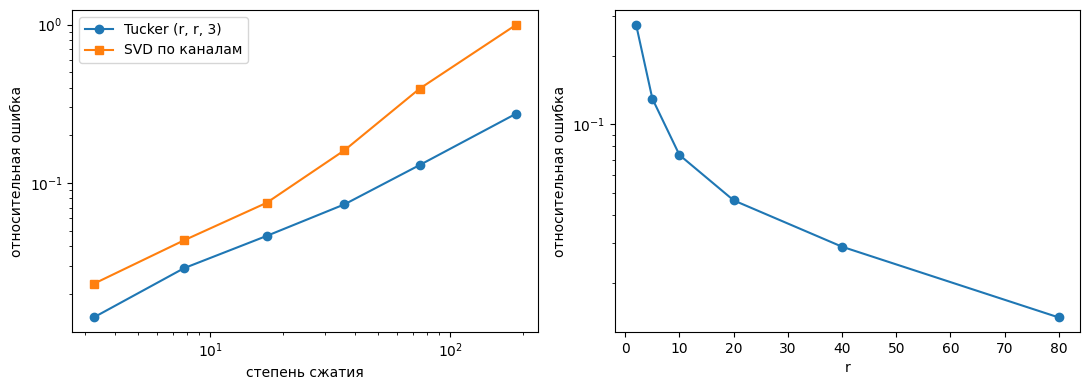

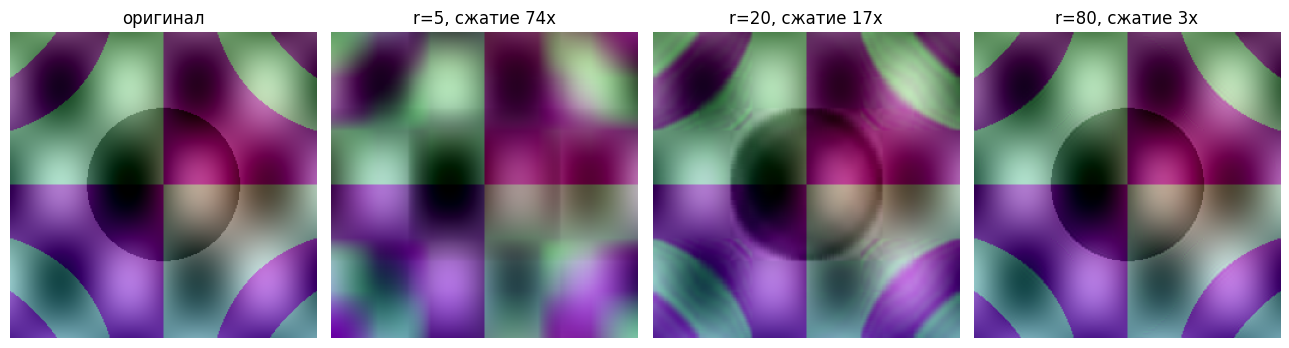

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(res['сжатие, раз'], res['ошибка Tucker (r, r, 3)'], 'o-', label='Tucker (r, r, 3)')
ax[0].loglog(res['сжатие, раз'], res['ошибка поканального SVD'], 's-', label='SVD по каналам')
ax[0].set_xlabel('степень сжатия')
ax[0].set_ylabel('относительная ошибка')
ax[0].legend()
ax[1].semilogy(rs, res['ошибка Tucker (r, r, 3)'], 'o-')
ax[1].set_xlabel('r')
ax[1].set_ylabel('относительная ошибка')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(13, 3.5))
for a, r in zip(ax, [None, 5, 20, 80]):
    a.imshow((img if r is None else recon[r]).clamp(0, 1).numpy())
    a.set_title('оригинал' if r is None else f'r={r}, сжатие {res.loc[r, "сжатие, раз"]:.0f}x')
    a.axis('off')
plt.tight_layout()
plt.show()

Ранг по цветовой моде выше 3 бессмысленен просто по размеру оси, поэтому асимметричные ранги тут не трюк, а единственный разумный вариант: пространственные моды сжимаются в десятки раз, цветовая не сжимается вообще

Сравнение с поканальным SVD при равном бюджете параметров показывает, за счёт чего работает Tucker: он хранит одну пару пространственных базисов на все три канала плюс маленькое ядро, связывающее их с цветом, вместо трёх независимых наборов. Когда каналы сильно коррелированы (а у реальных изображений это почти всегда так, здесь общая яркостная компонента даёт 75% сигнала), общий базис выигрывает, потому что тратить память на три почти одинаковых набора сингулярных векторов не нужно

По картинкам видно типичное поведение малорангового сжатия: сначала пропадают резкие границы и мелкие детали, гладкие градиенты держатся до последнего. Это те же самые артефакты, что у SVD-сжатия матрицы, просто теперь они одинаковы во всех каналах, потому что базис общий

### Задача 2.2. Tensor-Train и проклятие размерности

Полный тензор порядка $N$ с размером моды $d$ занимает $d^N$ элементов — при $N=20$, $d=8$ это
$\sim 10^{18}$ чисел, физически невозможно хранить. Tensor-Train представляет тензор как цепочку
малых 3-мерных "ядер" $G_1, \ldots, G_N$ (каждое — $(r_{n-1}, d, r_n)$), и число параметров растёт
**линейно** по $N$, а не экспоненциально.

1. Постройте тензор 6-го порядка (размер моды 8 по каждой из 6 осей) с известным TT-рангом,
   явно перемножив TT-ядра.
2. Разложите его функцией `tensorly.decomposition.tensor_train` с разными рангами, сравните
   ошибку восстановления и число параметров с полным размером тензора.
3. Постройте (аналитически, без реального построения тензора — это невозможно уже при небольшом
   числе мод!) таблицу/график: как растёт число элементов полного тензора и число параметров
   TT-разложения (при фиксированном ранге) с увеличением числа мод от 2 до 20.

In [6]:
d, N, r = 8, 6, 4
gen = torch.Generator().manual_seed(5)
dims = [1] + [r] * (N - 1) + [1]
cores = [torch.randn(dims[i], d, dims[i + 1], generator=gen, dtype=torch.float64) / r ** 0.5
         for i in range(N)]
T6 = tl.tt_to_tensor(cores)
norm6 = torch.linalg.norm(T6)

rows = {}
for rr in [2, 3, 4, 6]:
    rank = [1] + [rr] * (N - 1) + [1]
    tt = tensor_train(T6, rank=rank)
    params = sum(int(np.prod(c.shape)) for c in tt)
    rows[f'TT-ранг {rr}'] = {
        'ошибка': (torch.linalg.norm(T6 - tl.tt_to_tensor(tt)) / norm6).item(),
        'параметров': params,
        'доля от полного тензора': params / T6.numel(),
    }
rows['полный тензор'] = {'ошибка': 0.0, 'параметров': T6.numel(), 'доля от полного тензора': 1.0}

res6 = pd.DataFrame(rows).T
assert res6.loc['TT-ранг 4', 'ошибка'] < 1e-10
res6.assign(ошибка=res6['ошибка'].map('{:.1e}'.format)).round(5)

,ошибка,параметров,доля от полного тензора
TT-ранг 2,7.7e-01,160.0,0.00061
TT-ранг 3,4.7e-01,336.0,0.00128
TT-ранг 4,2.0e-15,576.0,0.00220
TT-ранг 6,2.5e-15,1248.0,0.00476
полный тензор,0.0e+00,262144.0,1.00000


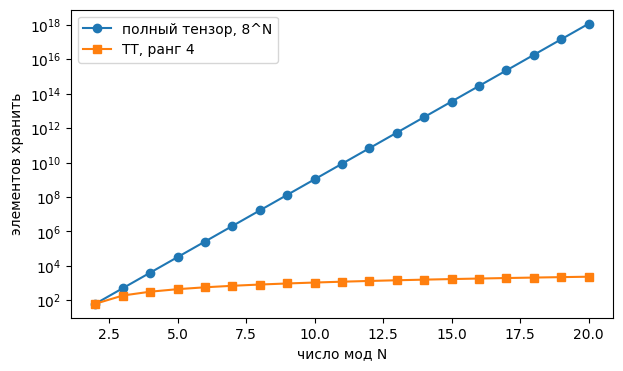

,полный тензор,TT,во сколько раз меньше
N,,,
2,64,64,1
6,2.62e+05,576,455
10,1.07e+09,1.09e+03,9.87e+05
14,4.4e+12,1.6e+03,2.75e+09
18,1.8e+16,2.11e+03,8.53e+12


In [7]:
Ns = np.arange(2, 21)
full = float(d) ** Ns
tt_params = 2 * d * r + (Ns - 2) * d * r ** 2

plt.figure(figsize=(7, 4))
plt.semilogy(Ns, full, 'o-', label=f'полный тензор, {d}^N')
plt.semilogy(Ns, tt_params, 's-', label=f'TT, ранг {r}')
plt.xlabel('число мод N')
plt.ylabel('элементов хранить')
plt.legend()
plt.show()

pd.DataFrame({'полный тензор': full[::4], 'TT': tt_params[::4],
              'во сколько раз меньше': full[::4] / tt_params[::4]},
             index=pd.Index(Ns[::4], name='N')).map('{:.3g}'.format)

TT-разложение точного ранга 4 восстанавливает тензор до машинной точности, ранг 2 даёт ошибку порядка десятков процентов, ранг 6 — ту же машинную точность, но с лишними параметрами. Здесь, в отличие от CP, нет никакой зависимости от инициализации: TT-SVD это последовательность обычных SVD от развёрток, детерминированный алгоритм с гарантией квазиоптимальности, а не ALS

Главная цифра — рост: полный тензор растёт как d^N, TT при фиксированном ранге как 2dr + (N−2)dr², то есть линейно по N. При N = 20 и d = 8 это 1.15e18 чисел против 2368, то есть разница в четырнадцать порядков. Именно поэтому таблицу приходится строить аналитически: полный тензор уже при N = 10 не помещается в память, а формула для числа параметров не требует его материализации

Практический смысл в том, что TT позволяет работать с объектами, которых физически нет в памяти: функцию многих переменных, решение уравнения на многомерной сетке или вероятностную таблицу хранят и складывают прямо в виде ядер, и стоимость операций тоже линейна по N

---
**Что сдавать:** ноутбук с реализованными функциями, графиками и письменными ответами на вопросы
для решённых задач. Требуется `pip install tensorly` (в Colab одна команда, без дополнительной
настройки). Все вычисления в сумме — не больше нескольких минут на CPU.